# 🏭 Projeto 1 — Dashboard Industrial
## Análise de Produção Industrial — Jan a Jun 2025

---

**Objetivo:** Construir um pipeline completo de análise de dados industriais — desde a limpeza até um dashboard visual — simulando o trabalho real de um analista de dados.

**Dataset:** `producao_industrial.csv`  
**Período:** Janeiro a Junho de 2025  
**Máquinas:** 5 (Torno CNC, Fresadora, Prensa Hidráulica, Injetora, Solda Robótica)  
**Registros:** ~1.935 linhas  

### 🗺️ Etapas do projeto:
1. Carregar e explorar os dados
2. Limpar e tratar inconsistências
3. Criar métricas e colunas derivadas
4. Análise exploratória completa
5. Dashboard visual com 4 subplots
6. Função de relatório gerencial
7. Exportar dados limpos

In [ ]:
#Importando todas as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1- Carregar e explorar os dados

In [ ]:
#Importando os dados

df = pd.read_csv('producao_industrial.csv')

# Inspeção dos dados
print(df.shape)
print("\n-----------------------------------------------\n")
print(df.info())
print("\n-----------------------------------------------\n")
print(df.describe())
print("\n-----------------------------------------------\n")
print(df.describe(include='object'))
print("\n-----------------------------------------------\n")
print(df.head(10))
print("\n-----------------------------------------------\n")
print(df.tail(5))



(1935, 12)

-----------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1935 entries, 0 to 1934
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   data                 1935 non-null   object 
 1   mes                  1935 non-null   object 
 2   dia_semana           1935 non-null   object 
 3   maquina              1935 non-null   object 
 4   tipo_maquina         1935 non-null   object 
 5   turno                1935 non-null   object 
 6   operador             1917 non-null   object 
 7   producao             1898 non-null   float64
 8   capacidade_maxima    1935 non-null   int64  
 9   tempo_parado_min     1935 non-null   int64  
 10  motivo_parada        1935 non-null   object 
 11  temperatura_celsius  1935 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 181.5+ KB
None

-----------------------------------------------

          pro

In [ ]:
# Criando cópia dos dados

df_limpo = df.copy()

## 2- Limpar e tratar inconsistências

## 🔎 Problemas Encontrados no Dataset

| Coluna              | Problema                                   | Detalhes |
|---------------------|---------------------------------------------|----------|
| **operador**        | Valores nulos                              | 18 valores nulos |
| **producao**        | Valores nulos                              | 37 valores nulos |
| **tempo_parado_min**| Valores negativos (impossível)             | mínimo = -5 |
| **temperatura_celsius** | Outliers                                | min = 36.1, max = 134.9 (valores suspeitos) |
| **maquina**         | Quantidade de categorias incorreta         | 10 valores únicos quando deveriam ser 5 (provavelmente m1, m2...) |
| **data**            | Tipo incorreto                             | tipo `object` em vez de `datetime`, precisa converter |

In [ ]:
# Corrigindo valores nulos em produção
""" Por a porcentagem de nulos ser baixa, preferi preencher os nulos pela mediana das máquinas e dos turnos """

df_limpo['producao'] = df_limpo.groupby(
    ['maquina', 'turno']
)['producao'].transform(lambda x: x.fillna(x.median()))

# Corrigindo nulos em operadores
""" Por se tratar do nome de pessoas, resolvi preencher com 'Não identificado' """

df_limpo['operador'] = df_limpo['operador'].fillna("Não informado")

# Corrigindo coluna máquina
""" Deixando as linhas padronizadas """

df_limpo['maquina'] = df_limpo['maquina'].str.upper().str.strip()

# Corrigindo a coluna data
""" A coluna data está definida como object e não como datetime """

df_limpo['data'] = pd.to_datetime(df_limpo['data'], format='%d/%m/%Y')

# Corrigindo negativos
""" Na coluna de tempo de parada existem números negativo, tempo parado negativo não existe """

df_limpo.loc[df_limpo['tempo_parado_min'] < 0, 'tempo_parado_min'] = np.nan

df_limpo['tempo_parado_min'] = df_limpo['tempo_parado_min'].fillna(0)

# Tratando outliners na coluna de temperatura
""" Vamos usar o IQR para definir os outliners """

Q1 = df_limpo['temperatura_celsius'].quantile(0.25)
Q3 = df_limpo['temperatura_celsius'].quantile(0.75)
IQR = Q3 - Q1

df_limpo['temperatura_celsius'] = df_limpo['temperatura_celsius'].clip(lower=Q1 - 1.5 * IQR,
    upper=Q3 + 1.5 * IQR)
# Verificação

print(df_limpo.isnull().sum())
print("\n-----------------------------------------------\n")
print(df_limpo.shape)
print("\n-----------------------------------------------\n")
print(df_limpo.info())
print("\n-----------------------------------------------\n")
print(df_limpo.describe())
print("\n-----------------------------------------------\n")
print(df_limpo.describe(include='object'))
print("\n-----------------------------------------------\n")
print(df_limpo.head(10))
print("\n-----------------------------------------------\n")
print(df_limpo.tail(5))



data                   0
mes                    0
dia_semana             0
maquina                0
tipo_maquina           0
turno                  0
operador               0
producao               0
capacidade_maxima      0
tempo_parado_min       0
motivo_parada          0
temperatura_celsius    0
dtype: int64

-----------------------------------------------

(1935, 12)

-----------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1935 entries, 0 to 1934
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 1935 non-null   datetime64[ns]
 1   mes                  1935 non-null   object        
 2   dia_semana           1935 non-null   object        
 3   maquina              1935 non-null   object        
 4   tipo_maquina         1935 non-null   object        
 5   turno                1935 non-null   object        
 6   operador

In [ ]:
# Verificação

print(df_limpo.isnull().sum())
print("\n-----------------------------------------------\n")
print(df_limpo.info())
print("\n-----------------------------------------------\n")
print(df_limpo['maquina'].unique())
print(df_limpo['maquina'].nunique())
print("\n-----------------------------------------------\n")
print(df_limpo.describe())
print("\n-----------------------------------------------\n")
print(df_limpo.describe(include='object'))
print("\n-----------------------------------------------\n")
print(df_limpo.head(10))
print("\n-----------------------------------------------\n")
print(df_limpo.tail(5))

data                   0
mes                    0
dia_semana             0
maquina                0
tipo_maquina           0
turno                  0
operador               0
producao               0
capacidade_maxima      0
tempo_parado_min       0
motivo_parada          0
temperatura_celsius    0
dtype: int64

-----------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1935 entries, 0 to 1934
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 1935 non-null   datetime64[ns]
 1   mes                  1935 non-null   object        
 2   dia_semana           1935 non-null   object        
 3   maquina              1935 non-null   object        
 4   tipo_maquina         1935 non-null   object        
 5   turno                1935 non-null   object        
 6   operador             1935 non-null   object        
 7   producao    

## 3- Criar métricas e colunas derivadas

In [ ]:
# Criando coluna de eficiência

df_limpo['eficiencia'] = df_limpo['producao'] / df_limpo['capacidade_maxima']
df_limpo['eficiencia'] = df_limpo['eficiencia'].clip(upper=1.0) # Existe registro de maquinas que produziram mais que sua capacidade

# Criando coluna status

def status_eficiencia(eficiencia):
  if eficiencia < 0.60:
    return "Crítico"
  elif eficiencia < 0.85:
    return "Normal"
  else:
    return "Ótimo"

df_limpo['status'] = df_limpo['eficiencia'].apply(status_eficiencia)



# Criando coluna de produção normalizada
df_limpo['producao_normalizada'] = (
    (df_limpo['producao'] - df_limpo['producao'].min()) /
    (df_limpo['producao'].max() - df_limpo['producao'].min())
)


df_limpo.head(10)

,data,mes,dia_semana,maquina,tipo_maquina,turno,operador,producao,capacidade_maxima,tempo_parado_min,motivo_parada,temperatura_celsius,eficiencia,status,producao_normalizada
0,2025-02-24,February 2025,Monday,M5,Solda Robotica,Manhã,Maria Lima,129.0,120,0.0,Sem parada,82.2,1.000000,Ótimo,0.237762
1,2025-03-26,March 2025,Wednesday,M1,Torno CNC,Tarde,Carlos Silva,150.0,160,0.0,Sem parada,67.4,0.937500,Ótimo,0.384615
2,2025-03-26,March 2025,Wednesday,M3,Prensa Hidráulica,Tarde,Ana Souza,136.0,140,0.0,Sem parada,85.5,0.971429,Ótimo,0.286713
3,2025-06-12,June 2025,Thursday,M5,Solda Robotica,Tarde,Maria Lima,123.0,120,0.0,Sem parada,69.7,1.000000,Ótimo,0.195804
4,2025-05-16,May 2025,Friday,M3,Prensa Hidráulica,Noite,Ana Souza,138.0,140,0.0,Sem parada,91.1,0.985714,Ótimo,0.300699
5,2025-04-25,April 2025,Friday,M2,Fresadora,Tarde,Ana Souza,189.0,180,0.0,Sem parada,84.0,1.000000,Ótimo,0.657343
6,2025-04-22,April 2025,Tuesday,M1,Torno CNC,Manhã,Ana Souza,158.0,160,0.0,Sem parada,72.3,0.987500,Ótimo,0.440559
7,2025-03-21,March 2025,Friday,M1,Torno CNC,Manhã,Pedro Santos,174.0,160,0.0,Sem parada,74.4,1.000000,Ótimo,0.552448
8,2025-04-25,April 2025,Friday,M1,Torno CNC,Manhã,Carlos Silva,160.0,160,0.0,Sem parada,78.7,1.000000,Ótimo,0.454545
9,2025-03-27,March 2025,Thursday,M4,Injetora,Noite,Maria Lima,180.0,200,0.0,Sem parada,99.6,0.900000,Ótimo,0.594406


## 4- Análise exploratória completa

In [ ]:
#  Produção e eficiência por máquina

df_limpo.groupby('maquina').agg({'producao':['sum', 'mean'], 'eficiencia': 'mean', 'tempo_parado_min': 'sum'}).round(2)

producao         eficiencia tempo_parado_min
             sum    mean       mean              sum
maquina                                             
M1       61152.0  158.02       0.96           1117.0
M2       69263.0  178.97       0.97            498.0
M3       53442.0  138.09       0.96           1492.0
M4       77026.5  199.03       0.97            666.0
M5       46102.0  119.13       0.96           2269.0

In [ ]:
#  Pivot Table: eficiência por máquina e turno
pd.pivot_table(df_limpo, values='eficiencia', index='maquina', columns='turno', aggfunc='mean', margins=True).round(2)

turno,Manhã,Noite,Tarde,All
maquina,,,,
M1,0.97,0.96,0.96,0.96
M2,0.97,0.97,0.97,0.97
M3,0.97,0.95,0.96,0.96
M4,0.97,0.96,0.97,0.97
M5,0.97,0.97,0.96,0.96
All,0.97,0.96,0.96,0.96


In [ ]:
# Evolução mensal da produção
df_limpo['mes_num'] = df_limpo['data'].dt.month #Retirando o mês da colina data

nome_mes = {1 : 'Janeiro', 2 : 'Fevereiro', 3 : 'Março', 4 : 'Abril', 5 : 'Maio', 6 : 'Junho'}

evolucao =  df_limpo.groupby('mes_num').agg({'producao':'sum', 'eficiencia':'mean'}).sort_values('mes_num').round(2)

evolucao.index = evolucao.index.map(nome_mes)
print(evolucao)

           producao  eficiencia
mes_num                        
Janeiro     54524.5        0.96
Fevereiro   47901.5        0.97
Março       50013.5        0.97
Abril       52075.0        0.96
Maio        52249.0        0.96
Junho       50222.0        0.97


In [ ]:
# Ranking de operadores
df_limpo.groupby('operador').agg(
    eficiencia_media = ('eficiencia', 'mean'),
    turnos_criticos  = ('status', lambda x: (x == 'Crítico').sum()),
    total_turnos     = ('eficiencia', 'count')
).round(3).sort_values('eficiencia_media', ascending=False)

,eficiencia_media,turnos_criticos,total_turnos
operador,,,
Maria Lima,0.966,0,408
Pedro Santos,0.965,0,404
João Pereira,0.964,0,382
Carlos Silva,0.963,0,382
Ana Souza,0.962,0,341
Não informado,0.955,0,18


## 5- Dashboard visual com 4 subplots

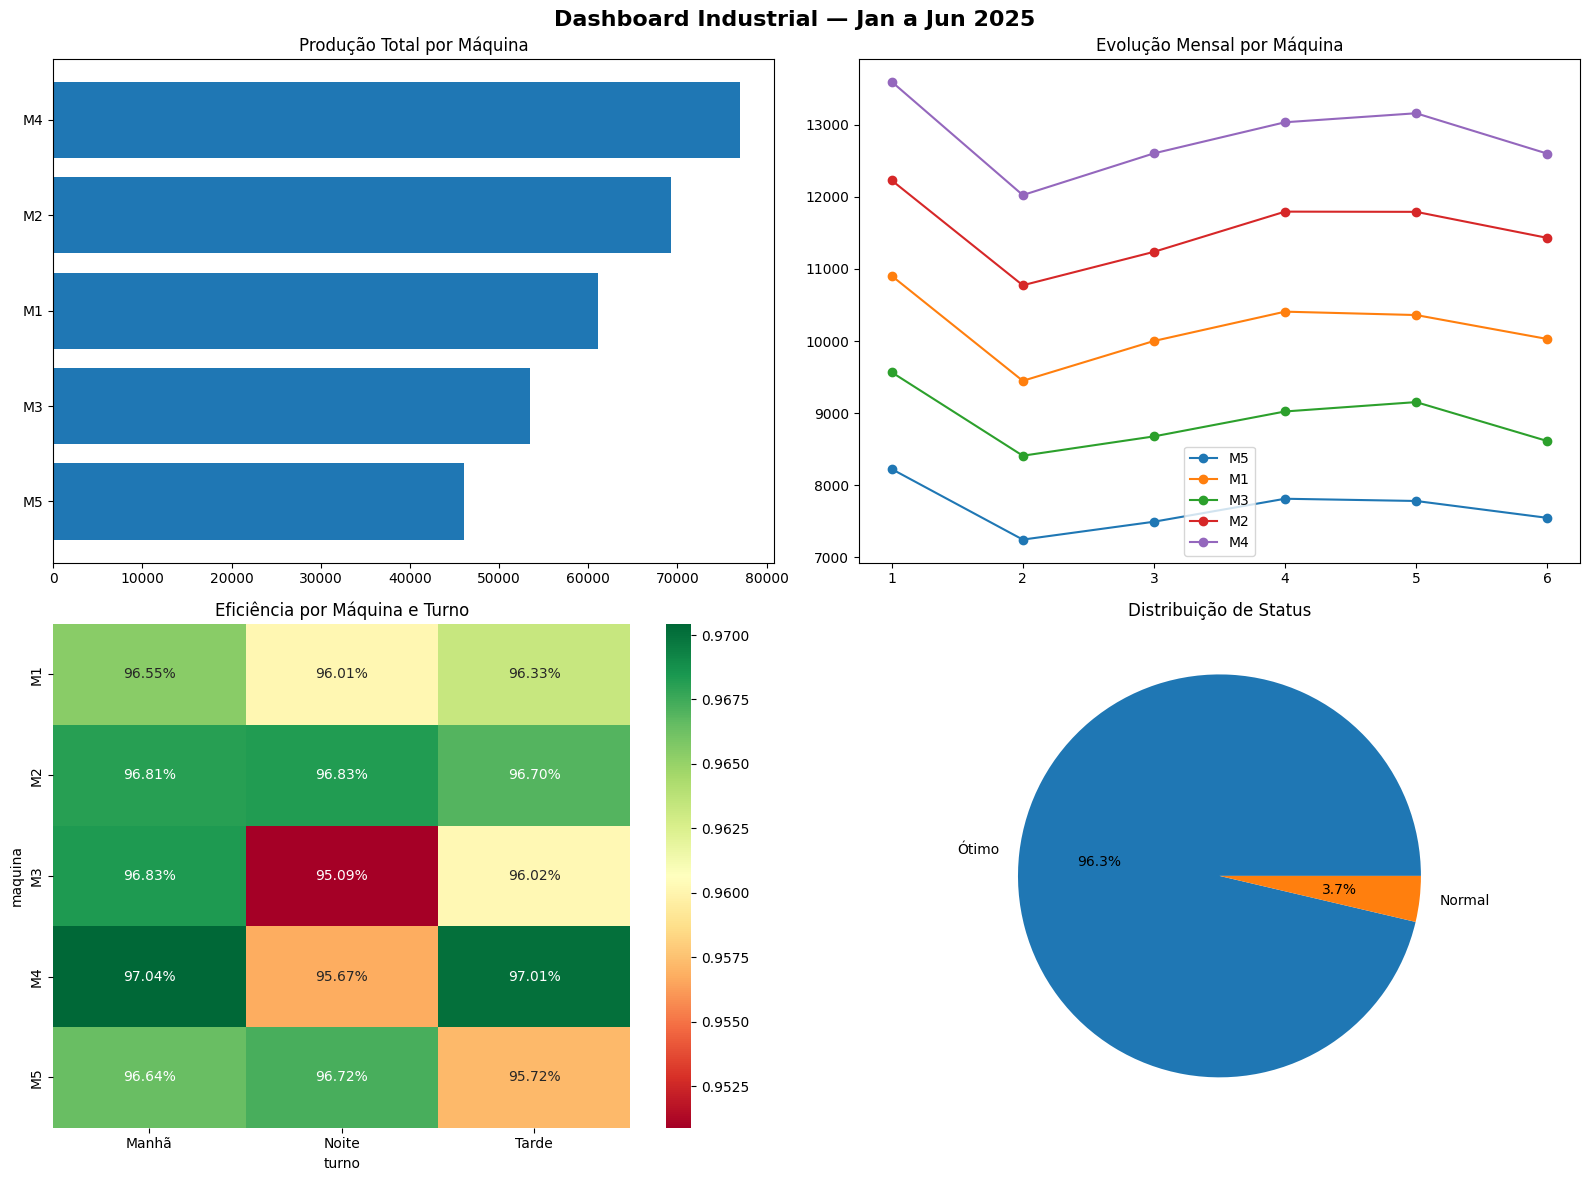

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard Industrial — Jan a Jun 2025',
             fontsize=16, fontweight='bold')
# Barras horizontais: produção total por máquina
prod_maquina = df_limpo.groupby('maquina')['producao'].sum().sort_values()

axes[0, 0].barh(prod_maquina.index, prod_maquina.values)
axes[0, 0].set_title('Produção Total por Máquina')

#  Linha: evolução mensal por máquina
for maquina in df_limpo['maquina'].unique():
    dados = df_limpo[df_limpo['maquina'] == maquina]
    dados_mes = dados.groupby('mes_num')['producao'].sum()
    axes[0, 1].plot(dados_mes.index, dados_mes.values,
                    marker='o', label=maquina)

axes[0, 1].legend()
axes[0, 1].set_title('Evolução Mensal por Máquina')

# Heatmap: eficiência por máquina e turno
pivot = df_limpo.pivot_table(values='eficiencia', index='maquina', columns='turno', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.2%',
            cmap='RdYlGn', ax=axes[1, 0])
axes[1, 0].set_title('Eficiência por Máquina e Turno')

# Pizza: distribuição de status
status_counts = df_limpo['status'].value_counts()
axes[1, 1].pie(status_counts.values,
               labels=status_counts.index,
               autopct='%1.1f%%')
axes[1, 1].set_title('Distribuição de Status')

plt.tight_layout()
plt.show()

## 6- Função de relatório gerencial

In [ ]:
#
pior_mes_num = df_limpo.groupby('mes_num')['producao'].sum().idxmin()

def gerar_relatorio(df):
    linha  = '=' * 50
    linha2 = '-' * 50

    print(linha)
    print("   RELATÓRIO GERENCIAL — PRODUÇÃO INDUSTRIAL")
    print(linha)
    print(f" Período   : {df['data'].min().strftime('%d/%m/%Y')} a {df['data'].max().strftime('%d/%m/%Y')}")
    print(f" Registros : {len(df):,} turnos")
    print(linha2)
    print("  PRODUÇÃO")
    print(f"    Total produzido  : {df['producao'].sum():,.0f} unidades")
    print(f"    Média por turno  : {df['producao'].mean():,.1f} unidades")
    print(linha2)

    print("  EFICIÊNCIA")
    print(f"    Eficiência geral : {df['eficiencia'].mean():.1%}")
    print(f"    Turnos Ótimos    : {((df['status'] == 'Ótimo').sum() / len(df)):.1%}")
    print(f"    Turnos Críticos  : {((df['status'] == 'Crítico').sum() / len(df)):.1%}")
    print(linha2)
    print("  DESTAQUES")
    print(f"     Máquina mais eficiente  : {df.groupby('maquina')['eficiencia'].mean().idxmax()}")
    print(f"     Máquina menos eficiente : {df.groupby('maquina')['eficiencia'].mean().idxmin()}")
    print(f"     Melhor operador         : {df[df['operador'] != 'Não informado'].groupby('operador')['eficiencia'].mean().idxmax()}")
    print(f"     Pior mês de produção    : {nome_mes[pior_mes_num]}")
    print(linha)

gerar_relatorio(df_limpo)

   RELATÓRIO GERENCIAL — PRODUÇÃO INDUSTRIAL
 Período   : 01/01/2025 a 30/06/2025
 Registros : 1,935 turnos
--------------------------------------------------
  PRODUÇÃO
    Total produzido  : 306,986 unidades
    Média por turno  : 158.6 unidades
--------------------------------------------------
  EFICIÊNCIA
    Eficiência geral : 96.4%
    Turnos Ótimos    : 96.3%
    Turnos Críticos  : 0.0%
--------------------------------------------------
  DESTAQUES
     Máquina mais eficiente  : M2
     Máquina menos eficiente : M3
     Melhor operador         : Maria Lima
     Pior mês de produção    : Fevereiro


## 7- Exportar dados limpos

In [ ]:
# Exportando

df_limpo.to_csv('producao_limpa.csv', index=False, encoding='utf-8-sig')
print(f'✅ Arquivo exportado!')
print(f'   Linhas  : {len(df_limpo):,}')
print(f'   Colunas : {len(df_limpo.columns)}')

✅ Arquivo exportado!
   Linhas  : 1,935
   Colunas : 16
